# AvianNet
**Objective:** Evaluate performance of 3 models on classifying 5 species of North American birds using Mel-Spectrograms.

**AvianNet V1:**
* Custom 3-layer architecture

**AvianNet V2:**
* Transfer learning using ResNet18
* Feature extraction by freezing model weights

**AvianNet V3:**
* Fine-tuned transfer learning using ResNet18




**Data Notes:** 
* Dataset is filtered using RMS energy to remove silent audio chunks (those lacking bird calls to predict off of).
* Moderate class imbalance was addressed using inverse frequency weighting in CrossEntropyLoss.
* Split was applied by unique recording ID to prevent data leakage across time-chunks.

**Blue Jay Mimicking:**
* The Blue Jay (Cyanocitta cristata) often mimics other birds in the wild, in particular, the Red-tailed hawks (Buteo jamaicensis) with high accuracy.
* Due to this, the model had some difficulty differentiating between Blue Jays and Red-tailed hawks.

In [20]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from pathlib import Path

from src.model import AvianNetModelV1, AvianNetModelV2
from src.dataset import get_dataloaders
from src.config_loader import load_config

In [21]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = AvianNetModelV1(input_shape=3, hidden_units=32, output_shape=5).to(device)

model_path = Path.cwd() / 'models' / 'avian_net_V1.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model weights loaded")

train_dataloader, test_dataloader = get_dataloaders()
all_preds = []
all_true_labels = []
print("Running inference on the test dataset.")

loss_fn =  nn.CrossEntropyLoss().to(device)
test_loss = 0

with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)
    
        
        
        # Convert logits to predicted class indices (0 through 4)
        logits = model(X_test)

        preds = logits.argmax(dim=1).cpu().numpy()
        true_labels = y_test.cpu().numpy()

        # Compute Loss
        test_loss += loss_fn(logits, y_test).item() * X_test.size(0)



        # Store for the confusion matrix
        all_preds.extend(preds)
        all_true_labels.extend(true_labels)

test_loss = (test_loss / len(test_dataloader.dataset))
print(f"Inference complete. Processed {len(all_preds)} audio chunks.")
print(f"Test Loss: {test_loss:.4f}")

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.
Test Loss: 0.5927


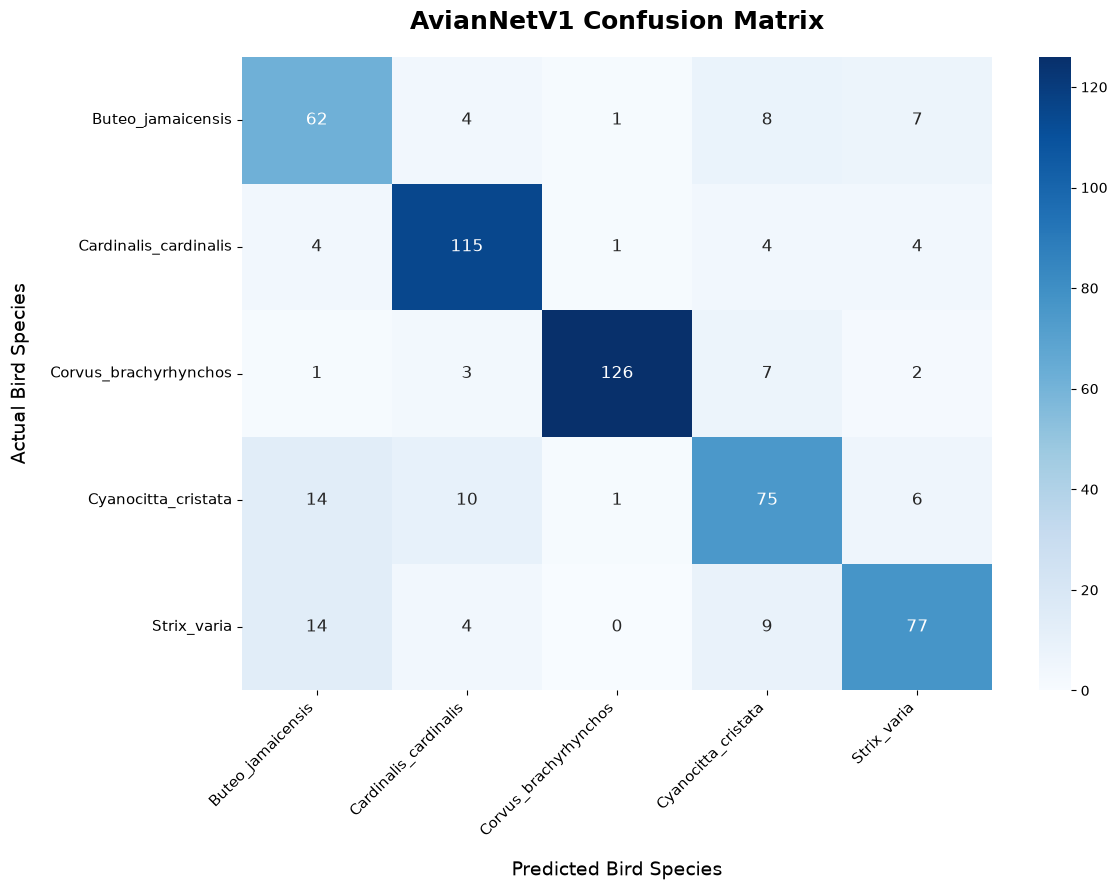

Classification Report - AvianNet V1
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.65      0.76      0.70        82
Cardinalis_cardinalis       0.85      0.90      0.87       128
Corvus_brachyrhynchos       0.98      0.91      0.94       139
  Cyanocitta_cristata       0.73      0.71      0.72       106
          Strix_varia       0.80      0.74      0.77       104

             accuracy                           0.81       559
            macro avg       0.80      0.80      0.80       559
         weighted avg       0.82      0.81      0.82       559



In [22]:
# Create the confusion matrix
cm= confusion_matrix(all_true_labels, all_preds)
dataset_dict = test_dataloader.dataset.species_to_idx_dict
bird_classes = [name for name, index in sorted(dataset_dict.items(), key=lambda x: x[1])]

# Matrix Plotting
plt.figure(figsize=(12, 9))
sns.heatmap(cm, 
            annot=True,       
            fmt='d',     
            cmap='Blues',
            xticklabels=bird_classes, 
            yticklabels=bird_classes,
            annot_kws={"size": 12})

plt.title('AvianNetV1 Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Bird Species', fontsize=14, labelpad=15)
plt.ylabel('Actual Bird Species', fontsize=14, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

report = classification_report(
    all_true_labels,
    all_preds,
    target_names=bird_classes
)
print("Classification Report - AvianNet V1")
print("-" * 50)
print(report)

In [23]:
# LR = 0.001, weights frozen

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = AvianNetModelV2(num_classes=5, freeze_weights=True).to(device)

model_path = Path.cwd() / 'models' / 'avian_net_V2.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model weights loaded")

train_dataloader, test_dataloader = get_dataloaders()
all_preds = []
all_true_labels = []
print("Running inference on the test dataset.")

loss_fn =  nn.CrossEntropyLoss().to(device)
test_loss = 0

with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)
    
        
        
        # Convert logits to predicted class indices (0 through 4)
        logits = model(X_test)

        preds = logits.argmax(dim=1).cpu().numpy()
        true_labels = y_test.cpu().numpy()

        # Compute Loss
        test_loss += loss_fn(logits, y_test).item() * X_test.size(0)



        # Store for the confusion matrix
        all_preds.extend(preds)
        all_true_labels.extend(true_labels)

test_loss = (test_loss / len(test_dataloader.dataset))
print(f"Inference complete. Processed {len(all_preds)} audio chunks.")
print(f"Test Loss: {test_loss:.4f}")

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.
Test Loss: 0.3766


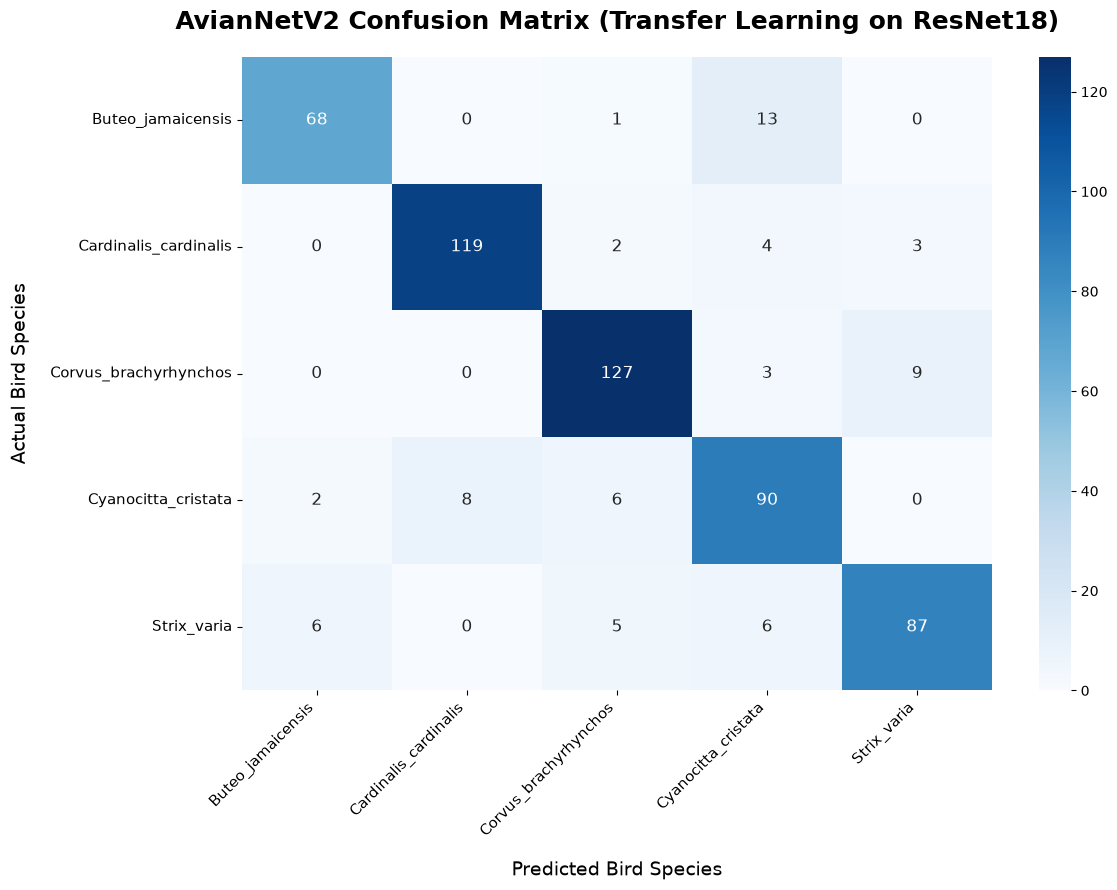

Classification Report - AvianNet V2
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.89      0.83      0.86        82
Cardinalis_cardinalis       0.94      0.93      0.93       128
Corvus_brachyrhynchos       0.90      0.91      0.91       139
  Cyanocitta_cristata       0.78      0.85      0.81       106
          Strix_varia       0.88      0.84      0.86       104

             accuracy                           0.88       559
            macro avg       0.88      0.87      0.87       559
         weighted avg       0.88      0.88      0.88       559



In [24]:
# Create the confusion matrix
cm = confusion_matrix(all_true_labels, all_preds)
dataset_dict = test_dataloader.dataset.species_to_idx_dict
bird_classes = [name for name, index in sorted(dataset_dict.items(), key=lambda x: x[1])]

# Matrix Plotting
plt.figure(figsize=(12, 9))
sns.heatmap(cm, 
            annot=True,       
            fmt='d',     
            cmap='Blues',
            xticklabels=bird_classes, 
            yticklabels=bird_classes,
            annot_kws={"size": 12})

plt.title('AvianNetV2 Confusion Matrix (Transfer Learning on ResNet18)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Bird Species', fontsize=14, labelpad=15)
plt.ylabel('Actual Bird Species', fontsize=14, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

report = classification_report(
    all_true_labels,
    all_preds,
    target_names=bird_classes
)
print("Classification Report - AvianNet V2")
print("-" * 50)
print(report)

In [25]:
# LR = 0.0001, Weights frozen
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = AvianNetModelV2(num_classes=5).to(device)

model_path = Path.cwd() / 'models' / 'avian_net_V3.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model weights loaded")

train_dataloader, test_dataloader = get_dataloaders()
all_preds = []
all_true_labels = []
print("Running inference on the test dataset.")

loss_fn =  nn.CrossEntropyLoss().to(device)
test_loss = 0

with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)
    
        
        
        # Convert logits to predicted class indices (0 through 4)
        logits = model(X_test)

        preds = logits.argmax(dim=1).cpu().numpy()
        true_labels = y_test.cpu().numpy()

        # Compute Loss
        test_loss += loss_fn(logits, y_test).item() * X_test.size(0)



        # Store for the confusion matrix
        all_preds.extend(preds)
        all_true_labels.extend(true_labels)

test_loss = (test_loss / len(test_dataloader.dataset))
print(f"Inference complete. Processed {len(all_preds)} audio chunks.")
print(f"Test Loss: {test_loss:.4f}")

Model weights loaded
Running inference on the test dataset.
Inference complete. Processed 559 audio chunks.
Test Loss: 0.3197


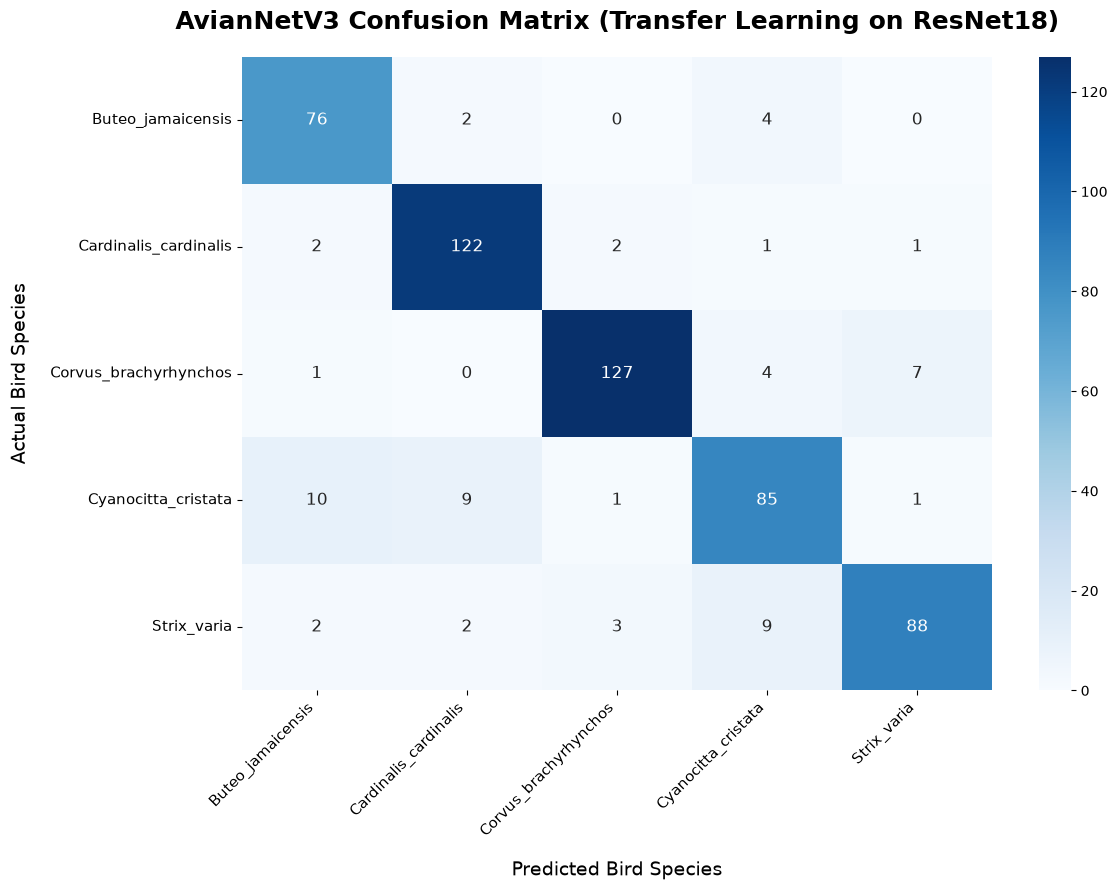

Classification Report - AvianNet V3
--------------------------------------------------
                       precision    recall  f1-score   support

    Buteo_jamaicensis       0.84      0.93      0.88        82
Cardinalis_cardinalis       0.90      0.95      0.93       128
Corvus_brachyrhynchos       0.95      0.91      0.93       139
  Cyanocitta_cristata       0.83      0.80      0.81       106
          Strix_varia       0.91      0.85      0.88       104

             accuracy                           0.89       559
            macro avg       0.89      0.89      0.89       559
         weighted avg       0.89      0.89      0.89       559



In [26]:
# Create the confusion matrix
cm = confusion_matrix(all_true_labels, all_preds)
dataset_dict = test_dataloader.dataset.species_to_idx_dict
bird_classes = [name for name, index in sorted(dataset_dict.items(), key=lambda x: x[1])]

# Matrix Plotting
plt.figure(figsize=(12, 9))
sns.heatmap(cm, 
            annot=True,       
            fmt='d',     
            cmap='Blues',
            xticklabels=bird_classes, 
            yticklabels=bird_classes,
            annot_kws={"size": 12})

plt.title('AvianNetV3 Confusion Matrix (Transfer Learning on ResNet18)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Predicted Bird Species', fontsize=14, labelpad=15)
plt.ylabel('Actual Bird Species', fontsize=14, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

report = classification_report(
    all_true_labels,
    all_preds,
    target_names=bird_classes
)
print("Classification Report - AvianNet V3")
print("-" * 50)
print(report)